# Using the Prediction Service

## 1 Query Function

In [1]:
import os

os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "learn-service-on-gcp-15c18be80a3f.json"

### 1.1 For AI Platform (obsolete)

In [2]:
# import googleapiclient.discovery

# project_id = "learn-service-on-gcp"
# model_id = "mnist_model"
# model_path = f"projects/{project_id}/models/{model_id}"
# output_name = "dense_1"
# ml_resource = googleapiclient.discovery.build("ml", "v1", cache_discovery=False).projects()

In [3]:
# from typing import Sequence

# import numpy as np

# def predict_ai_platform(X: Sequence[Sequence[Sequence[float]]]) -> np.ndarray:
#     input_data = {
#         "signature_name": "serving_default",
#         "instances": X.tolist() if isinstance(X, np.ndarray) else X,
#     }
#     request = ml_resource.predict(name=model_path, body=input_data)
#     response = request.execute()
#     if "error" in response:
#         raise RuntimeError(response["error"])

#     return np.array([pred[output_name] for pred in response["predictions"]])

### 1.2 For Vertex AI

In [4]:
endpoint = "https://europe-west3-aiplatform.googleapis.com/v1/projects/944005803524/locations/europe-west3/endpoints/808070677671182336"

In [5]:
from typing import Sequence

import numpy as np
from google.cloud import aiplatform


def predict_vertex_ai(
    instances: Sequence[Sequence[Sequence[float]]],
    project: str = "944005803524",
    location: str = "europe-west3",
    endpoint: str = "808070677671182336",
) -> np.ndarray:
    aiplatform.init(project=project, location=location)
    endpoint = aiplatform.Endpoint(endpoint)
    instances = instances.tolist() if isinstance(instances, np.ndarray) else instances

    prediction = endpoint.predict(instances=instances)

    return prediction

## 2 Data

In [6]:
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(f"x_train: {x_train.shape}")
print(f"y_test: {y_test.shape}")

2023-12-11 08:05:15.618111: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-11 08:05:15.667723: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-11 08:05:15.668379: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-12-11 08:05:16.665046: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


x_train: (60000, 28, 28)
y_test: (10000,)


## 3 Preprocessing

In [7]:
import pandas as pd

x_train, x_test = x_train / 255.0, x_test / 255.0
pd.Series(x_test.ravel()).describe()

count    7.840000e+06
mean     1.325146e-01
std      3.104803e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.000000e+00
dtype: float64

In [8]:
import numpy as np

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [9]:
x_test = x_test[:5, :, :, np.newaxis]

In [10]:
x_test.shape

(5, 28, 28, 1)

In [11]:
x_test.dtype

dtype('float32')

## 4 Prediction

In [12]:
response = predict_vertex_ai(instances=x_test)
response

Prediction(predictions=[[-4.38659286, -2.48233438, 1.61747134, -0.0353760496, -4.7459693, -4.10117483, -11.0737314, 18.2402725, -4.4090147, -0.334385574], [1.4806391, 2.50011492, 16.2644234, -2.55460286, -12.3951483, -9.91908073, -6.01224804, -2.48694468, 1.6106112, -7.08717537], [-2.6199317, 10.0377617, -4.86508608, -8.16425419, -4.27235889, -2.80467606, -3.95669532, 1.64303577, -0.814824939, -6.23935604], [13.8727255, -4.03839254, -1.29730415, 0.0927562341, -4.00259733, -0.690004945, 1.55418718, -1.11689758, -6.75886631, 0.798509657], [-4.66834927, -2.60283065, -2.82849407, -5.35470819, 11.6093082, -5.09479475, -4.53243637, -1.0203259, -4.99535322, 7.00375938]], deployed_model_id='4603162604288868352', model_version_id='1', model_resource_name='projects/944005803524/locations/europe-west3/models/1371777095092404224', explanations=None)

In [13]:
y_pred = np.argmax(response.predictions, axis=1)
y_pred

array([7, 2, 1, 0, 4])

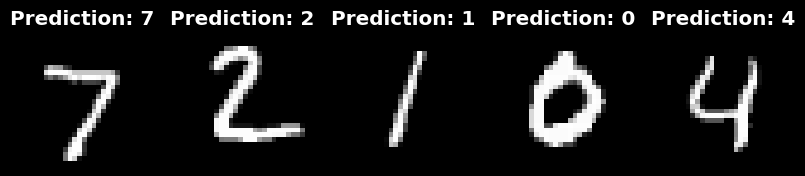

In [14]:
from data_science.util import print_images_in_subfigures

print_images_in_subfigures.print_images_in_subfigures(
    images=x_test, labels=y_pred, subtitle_prefix="Prediction", figsize=(10, 3)
)